Missing Values:
 Patient_ID        0
Age               0
Gender            0
Blood_Pressure    0
Sugar_Level       0
Cholesterol       0
Heart_Rate        0
dtype: int64

--- Descriptive Statistics ---
        Patient_ID           Age  Blood_Pressure   Sugar_Level   Cholesterol  \
count  10000.00000  10000.000000    10000.000000  10000.000000  10000.000000   
mean    5000.50000     50.290400      129.668100    135.618200    224.568500   
std     2886.89568     17.588957       29.138093     37.843946     43.604943   
min        1.00000     20.000000       80.000000     70.000000    150.000000   
25%     2500.75000     35.000000      104.000000    103.000000    187.000000   
50%     5000.50000     50.000000      130.000000    136.000000    224.000000   
75%     7500.25000     66.000000      155.000000    169.000000    262.000000   
max    10000.00000     80.000000      180.000000    200.000000    300.000000   

         Heart_Rate  
count  10000.000000  
mean      89.890900  
std       1

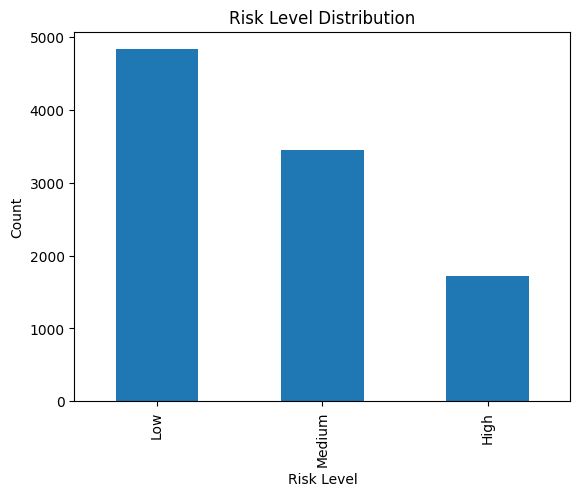

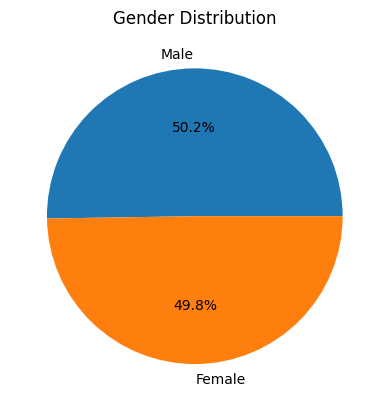

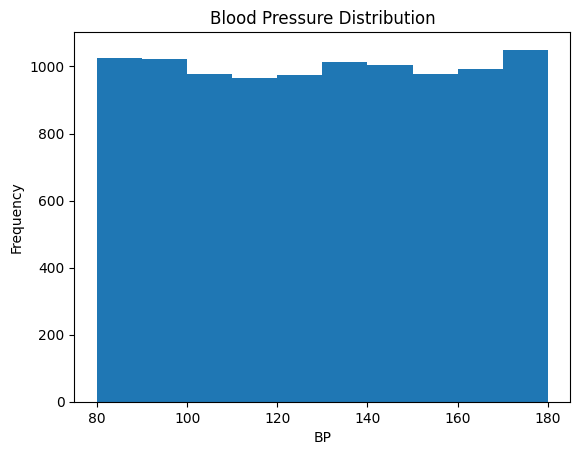

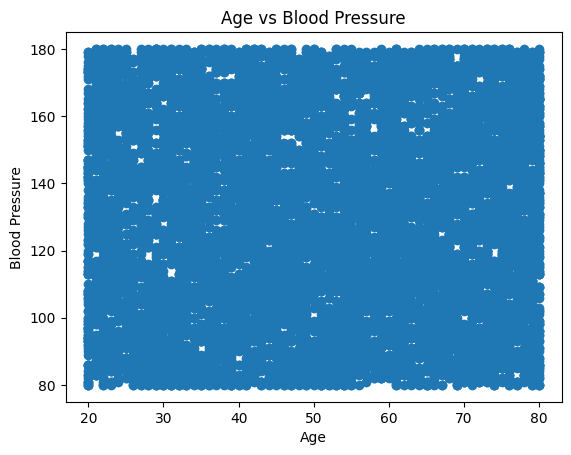

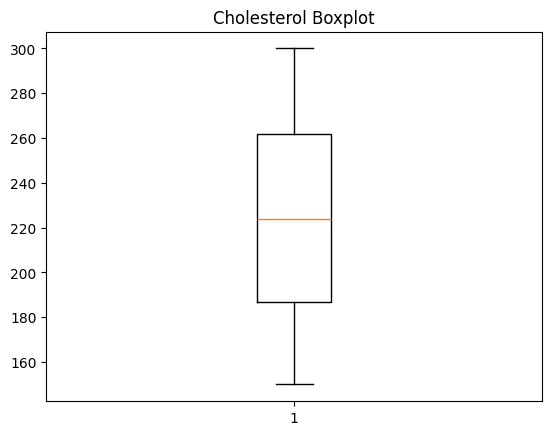

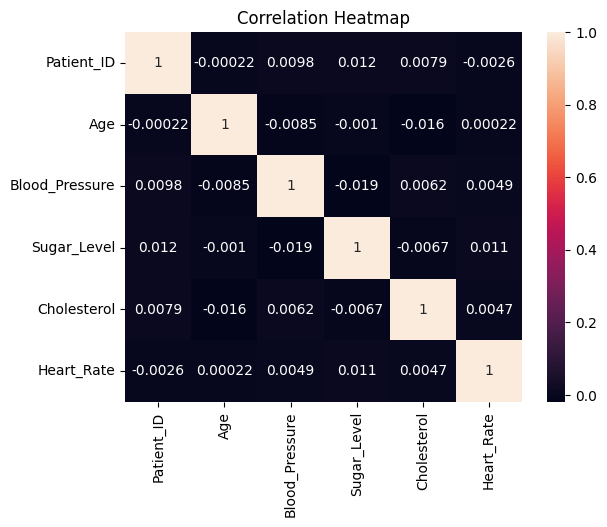


Dataset saved as healthcare_patient_data.csv


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Generate Synthetic Dataset
# -----------------------------

np.random.seed(42)
n = 10000

data = {
    "Patient_ID": range(1, n+1),
    "Age": np.random.randint(20, 81, n),
    "Gender": np.random.choice(['Male', 'Female'], n),
    "Blood_Pressure": np.random.randint(80, 181, n),
    "Sugar_Level": np.random.randint(70, 201, n),
    "Cholesterol": np.random.randint(150, 301, n),
    "Heart_Rate": np.random.randint(60, 121, n)
}

df = pd.DataFrame(data)

# -----------------------------
# 2. Data Cleaning
# -----------------------------

print("Missing Values:\n", df.isnull().sum())

# -----------------------------
# 3. Feature Engineering (Risk)
# -----------------------------

def classify_risk(row):
    risk_score = 0

    # Conditions (simple medical thresholds)
    if row["Blood_Pressure"] > 140:
        risk_score += 1
    if row["Sugar_Level"] > 140:
        risk_score += 1
    if row["Cholesterol"] > 240:
        risk_score += 1
    if row["Heart_Rate"] > 100:
        risk_score += 1

    # Classification
    if risk_score >= 3:
        return "High"
    elif risk_score == 2:
        return "Medium"
    else:
        return "Low"

df["Risk_Level"] = df.apply(classify_risk, axis=1)

# -----------------------------
# 4. Descriptive Statistics
# -----------------------------

print("\n--- Descriptive Statistics ---")
print(df.describe())

# -----------------------------
# 5. High Risk Patients
# -----------------------------

high_risk = df[df["Risk_Level"] == "High"]
print("\nNumber of High Risk Patients:", len(high_risk))

# -----------------------------
# 6. Group-Based Analysis
# -----------------------------

# Age groups
bins = [20, 35, 50, 65, 80]
labels = ['20-35', '36-50', '51-65', '66-80']
df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

print("\nAge Group vs Risk:")
print(pd.crosstab(df["Age_Group"], df["Risk_Level"]))

print("\nGender-wise Average Values:")
print(df.groupby("Gender")[["Blood_Pressure", "Sugar_Level", "Cholesterol", "Heart_Rate"]].mean())

print("\nRisk Distribution:")
print(df["Risk_Level"].value_counts())

# -----------------------------
# 7. Correlation Analysis
# -----------------------------

print("\nCorrelation Matrix:\n", df.corr(numeric_only=True))

# -----------------------------
# 8. Visualizations
# -----------------------------

# Bar Chart - Risk Distribution
df["Risk_Level"].value_counts().plot(kind='bar')
plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()

# Pie Chart - Gender
df["Gender"].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

# Histogram - Blood Pressure
plt.hist(df["Blood_Pressure"])
plt.title("Blood Pressure Distribution")
plt.xlabel("BP")
plt.ylabel("Frequency")
plt.show()

# Scatter - BP vs Age
plt.scatter(df["Age"], df["Blood_Pressure"])
plt.title("Age vs Blood Pressure")
plt.xlabel("Age")
plt.ylabel("Blood Pressure")
plt.show()

# Box Plot - Cholesterol
plt.boxplot(df["Cholesterol"])
plt.title("Cholesterol Boxplot")
plt.show()

# Heatmap (Correlation)
import seaborn as sns
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# -----------------------------
# 9. Save Dataset
# -----------------------------

df.to_csv("healthcare_patient_data.csv", index=False)

print("\nDataset saved as healthcare_patient_data.csv")